# <font color=red>< header >Agent篇

## 可以逛一下https://www.kingstone.com.tw/robots.txt<br/>
---
### [何謂robots.txt](https://zh.wikipedia.org/wiki/Robots.txt)
```
大部分的網站都會在網站的最底層，放一個robots.txt
當作布告欄。

#允許所有網路爬蟲
User-agent: *
Disallow:

#攔截所有網路爬蟲
User-agent: *
Disallow:/


#攔截所有網路爬蟲拜訪特定目錄
User-agent: *
Disallow: /*.asp$
Disallow: /*.html$


```


# <font color=red>讓我們用GET的方式來跟金石堂聊聊天

In [ ]:
#我們來金石堂找本書看看
import requests
url='https://www.kingstone.com.tw/basic/2014230080709?zone=book&lid=home_act_prod2'
html=requests.get(url)
print(html.status_code)

<h2 ><font color=red>當我們單純用requests.get()來讀取網站資料的時候，伺服器會對我們阻擋，因為它知道你是隻蟲，不是人。</font></h2>

# <span style="color:orange ">這時候，header就是一個關鍵

<h2 ><font color=red>我們需要把自己偽裝成一個人</font></h2>
<h4>關鍵就是在前端加入<strong>headers表頭</strong></h4>
<h4>裡面最重要的欄位就是<strong>'User-Agent'</strong></h4>
<h4>我們會透過<strong>'User-Agent'</strong>來向網站表明身分</h4>

----
# [我不懂什麼是User-Agent啦!](https://progressbar.tw/posts/234)
    

In [ ]:
#再訪金石堂
import requests
url='https://www.kingstone.com.tw/basic/2014230080709?zone=book&lid=home_act_prod2'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/138.0.0.0 Safari/537.36"
    )
}
html=requests.get(url,headers=headers)
print(html.status_code)
#你可以看到Requests還是準備它的header，只是把我們的添加上去
print(html.headers)

# <span style="color:red ">從Chrome裡面找到最好的User-agent設定

----
### 請在你的search Bar打" chrome://version/ "就知道了!
* Mozilla/5.0 (Windows NT 10.0; Win64; x64) 
* AppleWebKit/537.36 (KHTML, like Gecko) 
* Chrome/83.0.4103.97 
* Safari/537.36

# <font color=red>< header >Referer篇
----
## [範例網頁](http://www.webscrapingfordatascience.com/referercheck/)==>你應該可以看到秘密網頁
----
## [直接點秘密網頁](http://www.webscrapingfordatascience.com/referercheck/secret.php)==>啥咪??
----
    那這樣你要怎麼爬秘密網頁??

# <span style="color:orange ">如果爬的過程，無法獲得你要的結果，先用瀏覽器打開網頁，看看header的變化。

## <font color=red>< 小測驗 >嘗試幫我解決一下，看怎麼樣可以進入??

## <font color=red>< 答案 >

In [ ]:
import requests

url = "https://www.webscrapingfordatascience.com/referercheck/secret.php"

headers = {
    "Referer": "https://www.webscrapingfordatascience.com/referercheck/"
}

r = requests.get(url, headers=headers)

print(r.text)

# <font color=red>< cookie >
-------
    基本上的HTTP 的協議本身是「無記憶狀態 (Stateless) 」的。
    整個transaction完成以後，誰是誰都不記得。
    但是你想像一個狀態
    你在產品頁面，放東西進購物車，
    然後你到結帳畫面去，難道要你的客人再挑一次產品嗎?
    那他應該走了。

# <font color=red>認識Cookie
--------
      很多網站在你瀏覽網頁之後，會在你的電腦系統中留下一些小小的檔案，
      也就是所謂的 Cookie。當你再去瀏覽這些網站時，
      系統便會去讀取這些 Cookie 再更新儲存一遍。

      Cookie 不是「餅乾」，Cookie 是伺服器暫存在你電腦上的一筆資料，
      好讓伺服器用來辨認你的電腦。就好比是格林童話故事中，沿途撒下麵包屑避免在森林中迷路的小孩。



##    [Session與Cookie差別](https://medium.com/tsungs-blog/day14-session%E8%88%87cookie%E5%B7%AE%E5%88%A5-eb7b4035a382)

# <font color=red>Cookie怎麼用

-------
Response的時候，server會送回下面的檔案
    
    HTTP/1.1 200 OK
    Content-type: text/html
    Set-Cookie: sessionToken=20495; Expires=Wed, 09 Jun 2021 10:10:10 GMT
    Set-Cookie: siteTheme=dark
    [...]
-----
    1.header加入Set-Cookie
    2.cookie name 和 cookie value-
       會用=號連接成一組
       sessionToken=20495可能標註讀到哪一頁
       siteTheme=dark可能標註客人喜歡的網站配色
    3.如果有多個cookie值，就用;號分開

## <font color=red>< Cookie >做個實驗
----
## [網頁點我](http://www.webscrapingfordatascience.com/cookielogin/)
----
## 看到秘密網頁以後，如果你COPY網址，用另一個瀏覽器打開，可以打開嗎??

# <font color=red>< Cookie >同理，不掛Cookie，可以爬嗎?

In [ ]:
import requests
url = 'http://www.webscrapingfordatascience.com/cookielogin/secret.php'
r = requests.get(url)
print(r.text)

# <font color=red>< Cookie >加掛Cookie，出發

In [ ]:
import requests
url = 'http://www.webscrapingfordatascience.com/cookielogin/secret.php'
my_cookies = {'PHPSESSID': 'hfev8r5j3r6826tm4hl97elkj3'}
r = requests.get(url, cookies=my_cookies)
print(r.text)

## <span style="color:orange ">可以了!!但是說實話，我不知道這個密碼會不會改變，多久會改變??

# <font color=red>< 小測驗 >硬Key的code，不會是好code，可以幫我做一個可以自動更新內容的Smart Cookie嗎?

# <font color=red>< 答案 >還是要一鼓作氣解決

# <font color=red>< 小測驗 >嘿嘿!既然你已經會處理cookie了!!-談Redirect
-----
## [連結](http://www.webscrapingfordatascience.com/redirlogin/)
    
    那幫我爬一下下面網址
    http://www.webscrapingfordatascience.com/redirlogin/
    取得 secret code

# <font color=red>< 答案 >不要把我亂帶去別的地方
-----
### 依照下列方法觀察
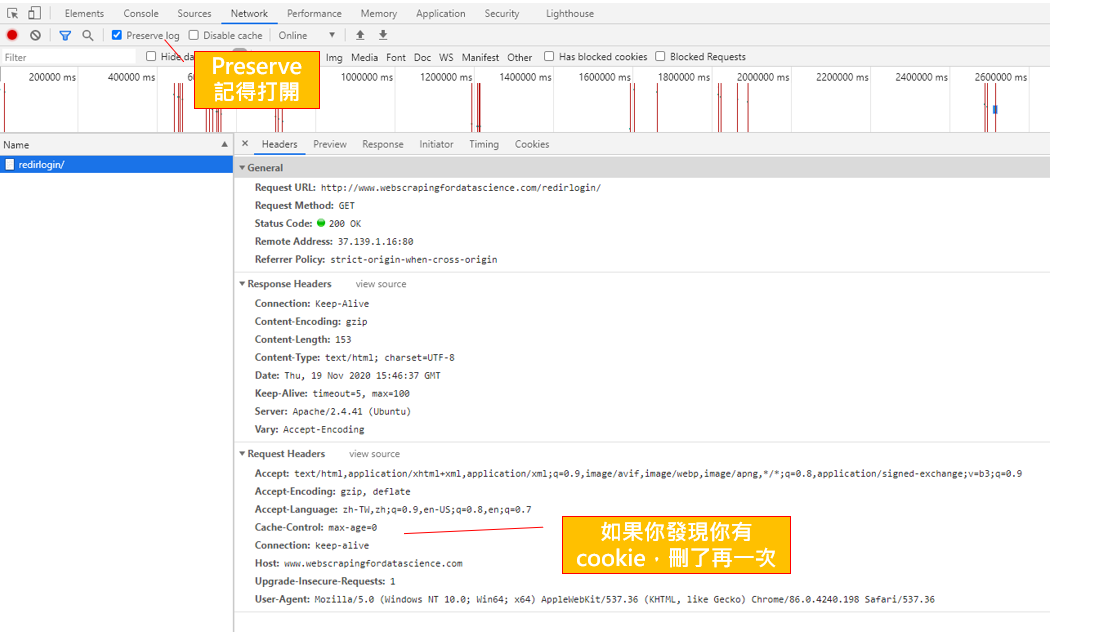

# <font color=red>< 小測驗 >再來一題
-----

## [連結](https://www.webscrapingfordatascience.com/trickylogin/) 
    那幫我爬一下下面網址
    https://www.webscrapingfordatascience.com/trickylogin/
    取得 secret code

# <font color=red>< 答案 >我只能說這就是爬蟲人生
-----
    1.你永遠要記得，防爬蟲最高竿的作法，就是在redirect的過程中，給你偷換cookie，你沒注意就被騙了!!  
    2.還要注意一下，request裡面有沒有被偷藏東西

# <font color=red>requests就是知道你的痛苦
-----
    1.Session()出動==>他會幫你處理後台所有cookie發生的一切事情。
    2.讓你跟server的溝通，完全彷彿就是一個真人  

# <font color=red>剛剛那題兩塊餅乾(兩次cookie轉換)的問題，再來一次

In [ ]:
import requests
url = 'http://www.webscrapingfordatascience.com/trickylogin/'
my_session = requests.Session()
r = my_session.get(url)
r = my_session.post(url, params={'p': 'login'},
                    data={'username': 'dummy', 'password': '1234'})

r = my_session.get(url, params={'p': 'protected'})
print(r.text)

# <font color=red>Session()還可以做更多
-----
    1.Session()除了可以讓你的request連貫起來
    2.還記得“User-Agent”嗎? 類似這種的global header fields，一次設定，萬家用
    

In [ ]:
import requests
from fake_useragent import UserAgent

ua = UserAgent()
url = 'http://www.webscrapingfordatascience.com/trickylogin/'
my_session = requests.Session()
#把agent設定進來
my_session.headers.update({'User-Agent': ua.random})

#開始用這個我們設定好的session開始作業:
r = my_session.post(url)
print(r.request.headers)
print(r.status_code)

r = my_session.post(url, params={'p': 'login'},
data={'username': 'dummy', 'password': '1234'})
print(r.request.headers)
print(r.status_code)

r = my_session.get(url, params={'p': 'protected'})
print(r.request.headers)
print(r.status_code)